In [1]:
from google.colab import files
uploaded = files.upload()

Saving Heart_Disease_Prediction.csv to Heart_Disease_Prediction.csv


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Heart_Disease_Prediction.csv")

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [6]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [7]:
le = LabelEncoder()

df["Heart Disease"] = le.fit_transform(df["Heart Disease"])

In [8]:
X = df.drop("Heart Disease", axis=1)

y = df["Heart Disease"]

In [11]:
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
y_pred = model.predict(X_test)

Confusion Matrix

[[31  2]
 [ 3 18]]


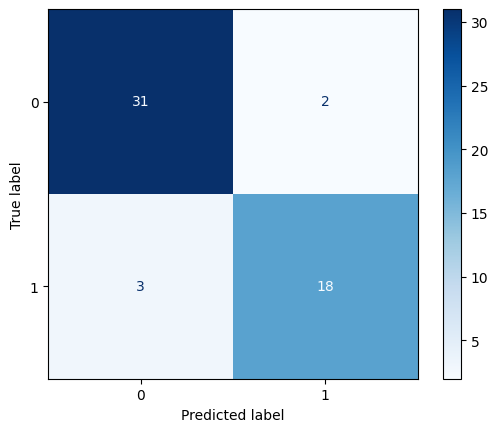

In [14]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.show()

Accuracy

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9074074074074074


Precision

In [16]:
precision = precision_score(y_test, y_pred)

print("Precision :", precision)

Precision : 0.9


Recall

In [17]:
recall = recall_score(y_test, y_pred)

print("Recall :", recall)

Recall : 0.8571428571428571


F1 Score

In [18]:
f1 = f1_score(y_test, y_pred)

print("F1 Score :", f1)

F1 Score : 0.8780487804878049


Classification Report

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



5-Fold Cross Validation

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(scores)

print("\nMean Accuracy:")
print(scores.mean())

Cross Validation Scores:
[0.7962963  0.81481481 0.88888889 0.81481481 0.87037037]

Mean Accuracy:
0.837037037037037


Model Comparison

In [22]:
print("Test Accuracy :", accuracy)
print("Cross Validation Mean :", scores.mean())

difference = abs(accuracy - scores.mean())

if difference < 0.02:
    print("\nModel Performance : BEST")
    print("Reason : Test accuracy and Cross Validation accuracy are almost the same, indicating excellent generalization.")
elif difference < 0.05:
    print("\nModel Performance : GOOD")
    print("Reason : Small difference between test accuracy and Cross Validation accuracy.")
else:
    print("\nModel Performance : NEEDS IMPROVEMENT")
    print("Reason : Large difference indicates possible overfitting or underfitting.")

Test Accuracy : 0.9074074074074074
Cross Validation Mean : 0.837037037037037

Model Performance : NEEDS IMPROVEMENT
Reason : Large difference indicates possible overfitting or underfitting.
